<a href="https://colab.research.google.com/github/fickas/crab_project/blob/main/salt_marsh_crab_unet_wellfleet_model1_training_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train model 1 on high res data

Will produce a model that can then be used in next notebook to fill out all pixels.

#Run once

In [ ]:
# Cell 1 — repo + dependencies
!git clone https://github.com/fickas/crab_project.git /content/marsh-crab 2>/dev/null || \
 (cd /content/marsh-crab && git pull)
!pip install -r /content/marsh-crab/requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 14.3 MB/s eta 0:00:00


#Wait until marsh-crab shows up locally

In [ ]:
# Cell 2 — Python setup
import sys
sys.path.insert(0, '/content/marsh-crab')
import marsh_utils as mu

##Run on changes

In [ ]:
# Run this cell whenever you edit the repo
!cd /content/marsh-crab && git pull
import importlib
importlib.reload(mu)

Already up to date.


<module 'marsh_utils' from '/content/marsh-crab/marsh_utils.py'>

#Build folder structure

<pre>
#
# Folder convention
# -----------------
#   {root}/
#     flights_1cm/{date}/                 a 1cm flight — always a ROOT (no linkage)
#       imagery/    pan.tif ms_5band.tif dem_5m.tif pansharp_5band.tif
#       bands/      ndvi.tif ndre.tif ...         (derived, regenerable)
#       labels/     handlabels.shp gt_labeled.gpkg
#       model/      runs/run_<ts>/ best_model.pt  (Model 1 for this flight)
#       predictions/ full_probs_<ts>.tif
#       review/     superpixels.tif abstain.tif review.gpkg
#       experiments/                             (band experiments, ablations — kept, not canonical)
#
#     flights_4cm/{date}/                 a 4cm flight — its OWN general info, plus
#       imagery/ bands/ labels/                   (the 4cm capture itself)
#       experiments/
#       linkage/from_1cm_{date}/          everything DERIVED from one 1cm model:
#         transfer/    label_4cm.tif abstain_4cm.tif superpix_4cm.tif review_4cm.gpkg *_legend.json
#         labels/      label_combined.tif         (transfer + this flight's handlabels)
#         model/       runs/run_<ts>/ best_model.pt   (Model 2 from this linkage)
#         predictions/ full_probs_<ts>.tif
#         review/      superpixels.tif abstain.tif review.gpkg   (Model 2's own abstains)
#       (a second linkage/from_1cm_<other>/ coexists cleanly — full provenance)
#
#     shared/       marsh-level, flight-independent (site polygon, etc.)
#     scratch/      disposable temp work — safe to wipe
#     archive/      legacy dirs moved out of the way
#
# The linkage/ subtree mirrors the portal's EvalResult.derived_from: 1cm = root,
# 4cm = derived-from-a-1cm. Deleting one linkage/from_1cm_<date>/ cleanly removes
# everything derived from that pairing, leaving the 4cm flight's own data intact.


</pre>

In [ ]:
# Standard scientific Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import json
import datetime

# Geospatial
import rasterio
from rasterio.mask import mask
from rasterio.features import rasterize
from rasterio.enums import Resampling
import geopandas as gpd
from shapely.geometry import box, mapping, Polygon
from shapely import wkt

# Image processing
import cv2
from PIL import Image

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Segmentation library
# May need to install: !pip install segmentation-models-pytorch
import segmentation_models_pytorch as smp

# Augmentation
# May need to install: !pip install albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metrics
from sklearn.metrics import confusion_matrix, classification_report

# Settings
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.11.0+cu128


In [ ]:
BATCH_SIZE = mu.recommended_batch_size()
BATCH_SIZE

GPU: NVIDIA A100-SXM4-80GB  (85.1 GB VRAM)


32

In [ ]:
DERIVED_BANDS = ['ndvi','ndre','savi','evi','gndvi','ndwi','ci_rededge',
                 'tpi_micro','tpi_small','tpi_large','hillshade','channel_mask',
                 'dist_to_channel','rel_elevation','local_std','laplacian',
                 'pan_range','dem_range','pan_entropy','dem_roughness']

#Reset this to real flight data when available

In [ ]:
base = "/content/drive/MyDrive/salt_marsh/crab_project/WEL/"
ortho_date = "2026-07-24"  #"2021-10-18"
ortho_name = "wel_2026_07_24_low_micap_100ft_ortho.tif"   #"18Oct21_WEL_Low_Mica_Ortho.tif"
dem_name = "wel_2026_07_24_low_micap_100ft_dem.tif"      #"18Oct21_WEL_Low_Mica_DEM.tif"

In [ ]:
the_gsd = "1cm"

In [ ]:
paths = mu.flight_paths(
    base, the_gsd, ortho_date,
    source_ortho_name = ortho_name,   # e.g. '18Oct21_WEL_Low_Mica_Ortho.tif'
    source_dem_name   = dem_name,     # e.g. '18Oct21_WEL_Low_Mica_DEM.tif'
    bands = DERIVED_BANDS,
)
Config = mu.make_config(BLOCK_SIZE_M=3 if ortho_date=='synthetic' else 100, BATCH_SIZE=BATCH_SIZE, GT_PATH=paths['gt_path'], GT_LAYER = 'ground_truth')

In [ ]:
mu.ensure_flight_dirs(paths)

{'_flight_dir': '/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24',
 '_imagery_dir': '/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/imagery',
 '_bands_dir': '/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands',
 '_labels_dir': '/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/labels',
 '_experiments_dir': '/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/experiments',
 '_source_dir': '/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/source',
 'pan_orthomosaic': '/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/imagery/pan.tif',
 'pansharp_ms': '/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/imagery/pansharp_5band.tif',
 'ms_5band': '/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/imagery/ms_5band.tif',
 'dem': '/content/drive/MyDrive/salt_marsh/crab_proje

In [ ]:
ortho_src = paths["source_ortho"]
ortho_src

'/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/source/wel_2026_07_24_low_micap_100ft_ortho.tif'

In [ ]:
synthetic = ortho_date == 'synthetic'

#Compute footprint unless already present

In [ ]:
if not synthetic and not os.path.exists(f'{paths['_flight_dir']}/footprint.geojson'):
    from osgeo import gdal
    import numpy as np, os
    gdal.UseExceptions()

    src = paths['source_ortho']

    # Auto-detect the nodata / margin value from a downsampled band 1
    ds = gdal.Open(src)
    print("dtype:", gdal.GetDataTypeName(ds.GetRasterBand(1).DataType))
    small = ds.GetRasterBand(1).ReadAsArray(buf_xsize=600, buf_ysize=600)
    vals, counts = np.unique(small, return_counts=True)
    fill = int(vals[counts.argmax()])
    print("dominant/margin value:", fill,
          f"({100*counts.max()/small.size:.0f}% of pixels)")
    print("corner:", int(small[0, 0]), " center:", int(small[small.shape[0]//2,
                                                             small.shape[1]//2]))
    ds = None

    # Trace the footprint using the detected nodata (destination FIRST, source second)
    if os.path.exists("footprint.geojson"):
        os.remove("footprint.geojson")
    d = gdal.Footprint(
        "footprint.geojson",     # destNameOrDestDS (destination first)
        src,                     # srcDS
        format="GeoJSON",
        dstSRS="EPSG:4326",      # lat/lng
        srcNodata=fill,          # auto-detected (e.g. 65535)
        maxPoints=300,
    )
    d = None
    print("wrote", os.path.getsize("footprint.geojson"), "bytes")
    import os
    print(os.path.getsize("footprint.geojson"))   # bytes — expect 0
    print(os.path.abspath("footprint.geojson"))    # where it wrote
    import json
    with open("footprint.geojson") as f:
        fc = json.load(f)          # context manager ensures full read
    print("features:", len(fc["features"]))
    print("geom type:", fc["features"][0]["geometry"]["type"])
    print("first coords:", fc["features"][0]["geometry"]["coordinates"][0][:2])


In [ ]:

with rasterio.open(paths["source_ortho"]) as src:
    print(src.count)         # 5
    print(src.descriptions)  # band names if the pipeline set them
    raw_bands = src.descriptions


6
('Blue', 'Green', 'Panchro', 'Red', 'Red edge', 'NIR')


In [ ]:
from osgeo import gdal
ds = gdal.Open(paths['source_ortho'])
gt = ds.GetGeoTransform()
print(f"pixel size: {gt[1]*100:.2f} cm × {abs(gt[5])*100:.2f} cm")
print(f"dimensions: {ds.RasterXSize} × {ds.RasterYSize}, bands: {ds.RasterCount}")
ds = None

pixel size: 1.76 cm × 1.76 cm
dimensions: 52054 × 64627, bands: 6


/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


#Do we need to break out different files?

Do bands appear in source as ('Blue', 'Green', 'Panchro', 'Red', 'Red edge', 'NIR')?

If so, need to break out.

In [ ]:
# ── Real-flight preprocessing: split the 6-band MicaSense ortho into the files
#    the pipeline expects. Assumes band order B,G,Panchro,R,RE,NIR (from QGIS).
#
#    6-band ortho  ->  pan.tif            (Panchro, band 3)          -> imagery/
#                      pansharp_5band.tif (B,G,R,RE,NIR: 1,2,4,5,6)  -> imagery/
#
#    Dropping Panchro leaves B,G,R,RE,NIR — the synthetic band order — so
#    ensure_indices runs with its ORIGINAL defaults (red=3, re=4, nir=5) on the
#    extracted pansharp_5band. No band-index override needed downstream.
#
#    Run in Colab. paths from flight_paths(...). GDAL (osgeo) available.

from osgeo import gdal
import os
gdal.UseExceptions()


def split_micasense_ortho(src_path, pan_out, pansharp_out,
                          pan_band=3, ms_bands=(1, 2, 4, 5, 6), overwrite=False):
    """Split a stacked 6-band ortho into a single-band pan and a 5-band MS stack.

    src_path     : the 6-band ortho (B,G,Panchro,R,RE,NIR)
    pan_out      : output path for the Panchro single band  (imagery/pan.tif)
    pansharp_out : output path for the 5-band MS stack       (imagery/pansharp_5band.tif)
    pan_band     : 1-based index of the Panchro band (3 here)
    ms_bands     : 1-based indices of the MS bands to keep, in output order
                   (1,2,4,5,6 = B,G,R,RE,NIR — drops Panchro at 3)
    """
    for out in (pan_out, pansharp_out):
        os.makedirs(os.path.dirname(out), exist_ok=True)
        if os.path.exists(out) and not overwrite:
            print(f"exists, skipping (overwrite=False): {out}")

    src = gdal.Open(src_path)
    nb = src.RasterCount
    print(f"source: {src_path}\n  {src.RasterXSize}×{src.RasterYSize}, {nb} bands, "
          f"px={src.GetGeoTransform()[1]*100:.2f}cm")
    assert nb >= max(max(ms_bands), pan_band), \
        f"source has {nb} bands but indices reference up to {max(max(ms_bands),pan_band)}"

    # ── pan.tif : the Panchro band, LZW-compressed, preserve georef ──
    if overwrite or not os.path.exists(pan_out):
        gdal.Translate(pan_out, src, bandList=[pan_band],
                       creationOptions=["COMPRESS=LZW", "TILED=YES", "BIGTIFF=IF_SAFER"])
        print(f"wrote pan  -> {pan_out}  (band {pan_band} = Panchro)")

    # ── pansharp_5band.tif : the MS bands in B,G,R,RE,NIR order ──
    if overwrite or not os.path.exists(pansharp_out):
        gdal.Translate(pansharp_out, src, bandList=list(ms_bands),
                       creationOptions=["COMPRESS=LZW", "TILED=YES", "BIGTIFF=IF_SAFER"])
        print(f"wrote pansharp -> {pansharp_out}  (bands {ms_bands} = B,G,R,RE,NIR)")

    src = None

    # verify outputs
    for out, expect in ((pan_out, 1), (pansharp_out, len(ms_bands))):
        d = gdal.Open(out)
        print(f"  check {os.path.basename(out)}: {d.RasterCount} band(s), "
              f"px={d.GetGeoTransform()[1]*100:.2f}cm")
        assert d.RasterCount == expect
        d = None
    print("done.")

if raw_bands == ('Blue', 'Green', 'Panchro', 'Red', 'Red edge', 'NIR'):
    assert False, 'check if have already split'
    split_micasense_ortho(
        src_path     = paths['source_ortho'],       # the 6-band ortho
        pan_out      = paths['pan_orthomosaic'],     # imagery/pan.tif
        pansharp_out = paths['pansharp_ms'],         # imagery/pansharp_5band.tif
        pan_band     = 3,                            # Panchro
        ms_bands     = (1, 2, 4, 5, 6),              # B,G,R,RE,NIR (drops Panchro)
    )
else: pass

AssertionError: check if have already split

#check if need to align ortho an dem

In [ ]:
paths['dem'] = mu.align_dem_to_ortho(
    paths['dem'], paths['pansharp_ms'],
    out_path=f"{paths['_source_dir']}/dem_aligned.tif",
    resample=True,   # ← fractional offset needs resampling
)

  resampled DEM already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/source/dem_aligned.tif, skipping


##Compute derived bands and save to disk (or just load)

In [ ]:
paths = mu.ensure_indices(paths)
print(paths['ndvi'])
print(paths['ndre'])

NDVI:
  exists, skipping: /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/ndvi.tif
NDRE:
  exists, skipping: /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/ndre.tif
/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/ndvi.tif
/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/ndre.tif


In [ ]:
print(paths['ndvi'])   # expect .../bands/ndvi.tif
import os
print(os.path.exists(paths['ndvi']))   # expect True (already there for synthetic)

/content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/ndvi.tif
True


##More bands
<pre>
Config.BAND_SPEC = [
    ('pan_orthomosaic', 1),
    ('ndvi',            1),
    ('slope',           1),      # ← swap in
    ('savi',            1),      # ← or add a 4th
]
</pre>

In [ ]:
import gc
gc.set_debug(gc.DEBUG_STATS | gc.DEBUG_COLLECTABLE)

# ── Spectral indices (read from pansharp_ms) ──
mu.ensure_savi(paths,       ms_key='pansharp_ms')
mu.ensure_evi(paths,        ms_key='pansharp_ms')
mu.ensure_gndvi(paths,      ms_key='pansharp_ms')
mu.ensure_ndwi(paths,       ms_key='pansharp_ms')
mu.ensure_ci_rededge(paths, ms_key='pansharp_ms')

# ── DEM-derived ──
mu.ensure_tpi(paths, dem_key='dem', neighborhood_m=0.05, out_key='tpi_micro')
gc.collect()
mu.ensure_tpi(paths, dem_key='dem', neighborhood_m=0.3,  out_key='tpi_small')
gc.collect()
mu.ensure_tpi(paths, dem_key='dem', neighborhood_m=2.0,  out_key='tpi_large')
gc.collect()
print('checkpoint q')
# Optional, only if you want a non-redundant slope signal:
# mu.ensure_slope(paths, dem_key='dem_high_res', smooth_sigma_m=0.05, out_key='slope')

# QGIS visualization only — don't put in BAND_SPEC:
mu.ensure_hillshade(paths, dem_key='dem')
gc.collect()


  SAVI already exists, skipping
  EVI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/evi.tif, skipping
  GNDVI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/gndvi.tif, skipping
  NDWI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/ndwi.tif, skipping
  CIred-edge already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/ci_rededge.tif, skipping
  TPI(0.05m) already exists, skipping


gc: collecting generation 2...
gc: objects in each generation: 459 0 587570
gc: objects in permanent generation: 375
gc: collectable <FreezableDefaultDict 0x7d5153ab4890>
gc: collectable <FreezableDefaultDict 0x7d5153ab4830>
gc: collectable <dict 0x7d5153ac1300>
gc: collectable <dict 0x7d5153ac0f00>
gc: collectable <FreezableDefaultDict 0x7d5153ab48f0>
gc: collectable <FreezableDefaultDict 0x7d5153ab49b0>
gc: collectable <dict 0x7d5153ac1280>
gc: collectable <dict 0x7d5153ac1180>
gc: collectable <FreezableDefaultDict 0x7d5153ab4a10>
gc: collectable <FreezableDefaultDict 0x7d5153ab4950>
gc: collectable <dict 0x7d5153ac0500>
gc: collectable <dict 0x7d5153ac12c0>
gc: collectable <function 0x7d515e4acf40>
gc: collectable <function 0x7d5153acc900>
gc: collectable <function 0x7d515e4ad080>
gc: collectable <function 0x7d5153acca40>
gc: collectable <function 0x7d515e4ad1c0>
gc: collectable <function 0x7d5153accb80>
gc: collectable <tuple 0x7d5153ad3430>
gc: collectable <tuple 0x7d5153aa37c0>
g

  TPI(0.3m) already exists, skipping


gc: done, 0 unreachable, 0 uncollectable, 0.2408s elapsed
gc: collecting generation 2...
gc: objects in each generation: 24 0 586358
gc: objects in permanent generation: 375


  TPI(2.0m) already exists, skipping


gc: done, 0 unreachable, 0 uncollectable, 0.2275s elapsed
gc: collecting generation 2...
gc: objects in each generation: 25 0 586358
gc: objects in permanent generation: 375


checkpoint q
  Hillshade already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/hillshade.tif, skipping


gc: done, 0 unreachable, 0 uncollectable, 0.2232s elapsed


0

In [ ]:

# ── Texture (from pan or any single-band raster) ──
mu.ensure_local_std(paths,  src_key='pan_orthomosaic', window_m=0.3)
gc.collect()
mu.ensure_laplacian(paths,  src_key='pan_orthomosaic')
gc.collect()

# Texture from pan brightness
mu.ensure_local_range(paths, src_key='pan_orthomosaic', window_m=0.3, out_key='pan_range')
gc.collect()
print('checkpoint 3')
# Topographic micro-relief (burrows!) from DEM
mu.ensure_local_range(paths, src_key='dem',    window_m=0.3, out_key='dem_range')
gc.collect()

# Entropy of pan = visual texture complexity
mu.ensure_local_entropy(paths, src_key='pan_orthomosaic', window_m=0.3, out_key='pan_entropy')
gc.collect()

# Existing function — DEM roughness via std
mu.ensure_local_std(paths, src_key='dem', window_m=0.3, out_key='dem_roughness')
gc.collect()

  local std already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/local_std.tif, skipping


gc: collecting generation 2...
gc: objects in each generation: 659 13 583438
gc: objects in permanent generation: 375
gc: done, 0 unreachable, 0 uncollectable, 0.2791s elapsed


  Laplacian already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/laplacian.tif, skipping


gc: collecting generation 2...
gc: objects in each generation: 26 0 584078
gc: objects in permanent generation: 375
gc: done, 0 unreachable, 0 uncollectable, 0.2768s elapsed


  local range already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/pan_range.tif, skipping


...

  local entropy already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/pan_entropy.tif, skipping


gc: collecting generation 2...
gc: objects in each generation: 20 0 584079
gc: objects in permanent generation: 375
gc: done, 0 unreachable, 0 uncollectable, 0.2771s elapsed


  local std already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/dem_roughness.tif, skipping


gc: collecting generation 2...
gc: objects in each generation: 19 0 584079
gc: objects in permanent generation: 375
gc: done, 0 unreachable, 0 uncollectable, 0.2747s elapsed


0

In [ ]:
import rasterio
for name, key in [('ortho', 'pansharp_ms'), ('dem', 'dem')]:
    with rasterio.open(paths[key]) as s:
        b = s.bounds
        print(f"{name}: {s.width}×{s.height}")
        print(f"   bounds: L={b.left:.1f} B={b.bottom:.1f} R={b.right:.1f} T={b.top:.1f}")
        print(f"   crs: {s.crs}")

ortho: 52054×64627
   bounds: L=323722.8 B=849334.7 R=324639.7 T=850473.0
   crs: EPSG:26986
dem: 98308×108554
   bounds: L=323364.3 B=848961.1 R=325096.0 T=850873.2
   crs: EPSG:26986


In [ ]:
import rasterio
with rasterio.open(paths['dem_range']) as s:
    print(s.width, s.height, s.count, dict(s.profile))

98308 108554 1 {'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 98308, 'height': 108554, 'count': 1, 'crs': CRS.from_wkt('PROJCS["NAD83 / Massachusetts Mainland",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",41],PARAMETER["central_meridian",-71.5],PARAMETER["standard_parallel_1",42.6833333333333],PARAMETER["standard_parallel_2",41.7166666666667],PARAMETER["false_easting",200000],PARAMETER["false_northing",750000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26986"]]'), 'transform': Affine(0.01761449999999996, 0.0, 323364.335124536,
       0.0, -0.017614499999999908, 850873.2229117232), 'blockxsize': 256, 'blockysize':

#Skip these for now?

They are memory hogs and could cause errors.

In [ ]:

# ── Channel-dependent (order matters: ndwi → channel_mask → the rest) ──
mu.ensure_ndwi(paths, ms_key='pansharp_ms')               # if not already done
gc.collect()
mu.ensure_channel_mask_from_ndwi(paths, ndwi_key='ndwi')  # needs ndwi
gc.collect()
mu.ensure_distance_to_channel(paths, channel_mask_key='channel_mask')
gc.collect()
mu.ensure_relative_elevation(paths, dem_key='dem',
                                channel_mask_key='channel_mask')
gc.collect()


  NDWI already exists at /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/ndwi.tif, skipping


gc: collecting generation 2...
gc: objects in each generation: 237 1837 586109
gc: objects in permanent generation: 375
gc: collectable <NameError 0x7d5335e649a0>
gc: collectable <traceback 0x7d5335ceb9c0>
gc: collectable <frame 0x7d5335cd4700>
gc: collectable <frame 0x7d5335f6b290>
gc: collectable <frame 0x7d5335fb9540>
gc: collectable <frame 0x7d5335fc2500>
gc: collectable <frame 0x7d5335e68e00>
gc: collectable <frame 0x7d5335e52440>
gc: collectable <frame 0x7d5335fa5cb0>
gc: collectable <frame 0x7d5335efb5e0>
gc: collectable <frame 0x7d5335e68f40>
gc: collectable <frame 0x7d5335e4f1f0>
gc: collectable <frame 0x7d5335cf4860>
gc: collectable <traceback 0x7d5335cebb80>
gc: collectable <ExecutionResult 0x7d5335ec7140>
gc: collectable <list 0x7d5335ce6680>
gc: collectable <list 0x7d5335ce6cc0>
gc: collectable <Module 0x7d5335f90890>
gc: collectable <function 0x7d5335ed19e0>
gc: collectable <list 0x7d5335ce7c40>
gc: collectable <With 0x7d5335f72590>
gc: collectable <cell 0x7d5335ec7250>
g

  wrote channel mask to /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/channel_mask.tif


gc: collecting generation 2...
gc: objects in each generation: 143 0 588040
gc: objects in permanent generation: 375
gc: done, 0 unreachable, 0 uncollectable, 0.2405s elapsed


  wrote distance-to-channel to /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/2026-07-24/bands/dist_to_channel.tif


gc: collecting generation 2...
gc: objects in each generation: 29 0 588152
gc: objects in permanent generation: 375
gc: done, 0 unreachable, 0 uncollectable, 0.2625s elapsed


In [ ]:
new_keys = ['savi', 'evi', 'gndvi', 'ndwi', 'ci_rededge',
            'tpi_micro', 'tpi_small', 'tpi_large',
            'hillshade', 'channel_mask', 'dist_to_channel',
            'rel_elevation', 'local_std', 'laplacian',
            'pan_range', 'dem_range', 'pan_entropy', 'dem_roughness']
missing = [k for k in new_keys if k not in paths]
print(f"Missing: {missing or 'none — all bands registered'}")

Missing: none — all bands registered


In [ ]:
import os
for k in new_keys:
    p = paths[k]
    print(f"{'✓' if os.path.exists(p) else '✗'} {k}: {os.path.basename(p)}")

✓ savi: savi.tif
✓ evi: evi.tif
✓ gndvi: gndvi.tif
✓ ndwi: ndwi.tif
✓ ci_rededge: ci_rededge.tif
✓ tpi_micro: tpi_micro.tif
✓ tpi_small: tpi_small.tif
✓ tpi_large: tpi_large.tif
✓ hillshade: hillshade.tif
✗ channel_mask: channel_mask.tif
✗ dist_to_channel: dist_to_channel.tif
✗ rel_elevation: rel_elevation.tif
✓ local_std: local_std.tif
✓ laplacian: laplacian.tif
✓ pan_range: pan_range.tif
✓ dem_range: dem_range.tif
✓ pan_entropy: pan_entropy.tif
✓ dem_roughness: dem_roughness.tif


In [ ]:
import os
print(paths['gt_path'], os.path.exists(paths['gt_path']))

In [ ]:
!pip install fiona
import fiona
print(fiona.listlayers(paths['gt_path']))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 139.9 MB/s eta 0:00:00
['ground_truth']


#Convert .shp to .gpkg if necessary

In [ ]:
force = False   #always create a new .gpkg even if already exists. Use this if want to start over completely. It will wipe out any active learning labeling that has occured.

In [ ]:
gt_gdf = gpd.read_file(paths['handlabels'])
if not os.path.exists(Config.GT_PATH) or force:
    gt_gdf.to_file(Config.GT_PATH, layer=Config.GT_LAYER, driver="GPKG")   # saves .gpkg version, used henceforth

#Block-based spatial splits


The block ID is (x // block_size, y // block_size). Two patches in the same block always go to the same split. A patch crossing a block boundary gets assigned by its center, so up to ~patch_size / 2 worth of pixels can leak into an adjacent block's split — at 256px × 1cm GSD that's 1.28m of leakage near 100m block boundaries, which is negligible.

#Patch generator with split assignments

The two-pass structure is so the block assignment is computed over the full set of blocks the raster touches, before any patches are yielded. Otherwise an early yielded patch's split could depend on which blocks get seen later, which would not be deterministic.

In [ ]:
polys_gdf = gt_gdf

###Map to 0-based and normalize the ground-truth data if not already done

normalizing it gets it ready for downstream active learning.

In [ ]:
polys_gdf.columns

Index(['Class', 'geometry'], dtype='object')

In [ ]:
mu.inspect_gt(Config, paths['handlabels'])
polys_gdf = mu.normalize_gt(Config, paths['handlabels'])  # idempotent
mu.write_gt(Config, polys_gdf, Config.GT_PATH)

# Catch unmapped values before they become silent bugs
if polys_gdf[Config.CLASS_COLUMN].isna().any():
    bad = polys_gdf.loc[polys_gdf[Config.CLASS_COLUMN].isna(), Config.CLASS_COLUMN].unique()
    raise ValueError(f"Unmapped class values from QGIS: {bad}")

polys_gdf[Config.CLASS_COLUMN] = polys_gdf[Config.CLASS_COLUMN].astype(int)

print(f"Class distribution:\n{polys_gdf[Config.CLASS_COLUMN].value_counts().sort_index()}")


99 features
columns : ['Class', 'geometry']
geometry: ['MultiPolygon', 'Polygon']
CRS     : EPSG:26919
already normalized? False
  class field 'Class': ['1', '2', '3', '4', '5', '6']
normalized 99 'pi_digitized' polys; class breakdown:
class_name
collapsed           11
crab_edge           26
crab_platform       13
eroding_non_crab    16
healthy_bank        32
other                1
wrote 99 polys -> /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/synthetic/labels/gt_labeled.gpkg (layer 'ground_truth')
Class distribution:
class_id
0     1
1    32
2    16
3    26
4    13
5    11
Name: count, dtype: int64


###Filter classes

Decide if whether to collapse classes into a subset.

In [ ]:
filter_classes = False

In [ ]:
if filter_classes:
  original_class_column = polys_gdf[Config.CLASS_COLUMN].copy()
  new_labels_master = []
  mapping = dict(zip(range(0,5), [1,0,2,2,2]))  #3 class - 2 will be dropped
  for i,label in enumerate(original_class_column):
    mapped_label = mapping[label]
    if mapped_label==2: continue  #skip
    new_labels_master.append(mapped_label)

  CLASS_NAMES = {
    0: 'healthy_bank',
    1: 'eroding_non_crab',
    2: 'collapsed',
  }

  polys_gdf[Config.CLASS_COLUMN] = np.array(new_labels_master)
  print(f"Class distribution:\n{polys_gdf[Config.CLASS_COLUMN].value_counts().sort_index()}")

In [ ]:

# 1. Generate patches with splits
patches = list(mu.build_patches_with_splits_multi(
    paths=paths,
    polygons_gdf=polys_gdf,
    cfg=Config,
))

# 2. Sanity-check coverage
mu.summarize_patches(patches, class_names=Config.CLASS_NAMES)

# 3. Split into train/val/test
train_patches = [p for p in patches if p['split'] == 'train']
val_patches   = [p for p in patches if p['split'] == 'val']
test_patches  = [p for p in patches if p['split'] == 'test']

# 4. Compute (or load cached) normalization stats from training patches
channel_means, channel_stds = mu.compute_channel_stats(train_patches, paths['channel_stats'])

# 5. Build datasets and loaders
train_ds = mu.MarshSegmentationDataset(train_patches, augmentation=mu.get_augmentations('train', channel_means, channel_stds))
val_ds   = mu.MarshSegmentationDataset(val_patches,   augmentation=mu.get_augmentations('val',   channel_means, channel_stds))
test_ds  = mu.MarshSegmentationDataset(test_patches,  augmentation=mu.get_augmentations('test',  channel_means, channel_stds))

train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True,  num_workers=Config.NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=True)

Total patches: 419
Splits: {'train': 287, 'test': 64, 'val': 68}

--- train: 287 patches, 75,235,328 pixels
  class   0 other                      27,967 ( 0.04%)
  class   1 healthy_bank            5,995,708 ( 7.97%)
  class   2 eroding_non_crab        2,292,976 ( 3.05%)
  class   3 crab_edge               3,849,229 ( 5.12%)
  class   4 crab_platform           2,328,246 ( 3.09%)
  class   5 collapsed               2,172,998 ( 2.89%)
  ignore (255)             58,568,204 (77.85%)

--- val: 68 patches, 17,825,792 pixels
  class   0 other                           0 ( 0.00%)
  class   1 healthy_bank            1,334,168 ( 7.48%)
  class   2 eroding_non_crab          830,080 ( 4.66%)
  class   3 crab_edge               1,060,384 ( 5.95%)
  class   4 crab_platform             663,076 ( 3.72%)
  class   5 collapsed                 453,809 ( 2.55%)
  ignore (255)             13,484,275 (75.64%)

--- test: 64 patches, 16,777,216 pixels
  class   0 other                      27,967 ( 0.17%)
  

###What to look for in smoke test

Once you've run the summary, three things to look for in the output:

* Are split sizes roughly proportional to your fractions (70/15/15)? If one block is huge relative to others, you may get an imbalanced split.
* Is each class present in every split? Empty val classes mean noisy IoU for that class.
* What does labeled_fraction look like? If most patches are less than 10% labeled, the model is mostly seeing ignore — you may want to filter more aggressively or oversample patches with high labeled_fraction.

* Many fewer patches than expected → tile labels don't cover most of the DEM and require_labels=True is dropping them. Lower the threshold to accept partially-labeled patches, or set require_labels=False to see what's there.

* Empty classes in val or test → block split landed unluckily. Try a different seed, or check whether the offending class is concentrated in a small geographic area (in which case a different split strategy might be warranted).

##Get stats for later normalization

#Start of training

## Model + optimizer + scheduler

In [ ]:
import segmentation_models_pytorch as smp

LR          = Config.LEARNING_RATE
WEIGHT_DECAY = 1e-4

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = smp.Unet(
    encoder_name=Config.ENCODER,
    encoder_weights=Config.ENCODER_WEIGHTS,
    in_channels=len(Config.BAND_SPEC),    # 3 for (Pan, NDVI, NDRE)
    classes=Config.N_CLASSES,
).to(device)

criterion = mu.CombinedLoss(
    num_classes=Config.N_CLASSES,
    ignore_index=255,
    ce_weight=1.0,
    dice_weight=1.0,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=Config.EPOCHS)

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 49.3MB            

model.safetensors: downloading bytes:           |  0.00B            

## Run it

In [ ]:
ckpt_path = f"{paths['artifacts']}/best_model.pt"

In [ ]:
best_iou = mu.train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=Config.EPOCHS,
    num_classes=Config.N_CLASSES,
    ignore_index=255,
    ckpt_path=ckpt_path,
    device=device,
    class_names=Config.CLASS_NAMES,
)
print(f"Best val mIoU: {best_iou:.4f}")

/content/marsh-crab/marsh_utils.py:1515: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch   1/100  train_loss=2.2542  val_loss=2.2925  val_mIoU=0.1187  |  other=0.000, healthy_bank=0.817, eroding_non_crab=0.006, crab_edge=0.145, crab_platform=0.003, collapsed=0.209
  → saved checkpoint  (val_mIoU=0.1187)
Epoch   2/100  train_loss=1.8196  val_loss=2.2644  val_mIoU=0.1327  |  other=0.000, healthy_bank=0.814, eroding_non_crab=0.017, crab_edge=0.140, crab_platform=0.003, collapsed=0.256
  → saved checkpoint  (val_mIoU=0.1327)
Epoch   3/100  train_loss=1.5714  val_loss=2.0459  val_mIoU=0.2818  |  other=0.000, healthy_bank=0.814, eroding_non_crab=0.065, crab_edge=0.368, crab_platform=0.018, collapsed=0.460
  → saved checkpoint  (val_mIoU=0.2818)
Epoch   4/100  train_loss=1.2853  val_loss=2.0904  val_mIoU=0.3147  |  other=0.000, healthy_bank=0.809, eroding_non_crab=0.014, crab_edge=0.357, crab_platform=0.014, collapsed=0.573
  → saved checkpoint  (val_mIoU=0.3147)
Epoch   5/100  train_loss=1.1889  val_loss=2.0377  val_mIoU=0.3851  |  other=0.000, healthy_bank=0.810, eroding_

##Watch list

* Loss going down. If it doesn't decrease over the first 3-5 epochs, something's wrong with the loss/optimizer/data. Most likely culprits: NaN in normalized inputs, label values outside [0, num_classes-1] ∪ {ignore_index}, learning rate way off.

* Train mIoU gt val mIoU as expected. If val tracks train almost exactly, your block-based splits aren't separating well enough — leakage. If val crashes far below train, you're overfitting and want more augmentation or fewer epochs.

* Per-class IoU. Rare classes (collapsed, eroding_non_crab maybe) will have noisier IoU. If a class stays at 0.0 IoU across epochs, the model isn't learning it — usually because there are too few pixels of it in train, or your class weights are pushing the model away from it.

##Need more than mIoU

The most useful metric isn't mIoU on the test set — it's precision at high-confidence thresholds. Specifically: "for pixels where Model 1 predicts class 3 with softmax ≥ 0.7, what fraction actually are class 3?" That high-confidence subset is what becomes Model 2's training data, and any false positives there poison Model 2.

So in addition to training-time mIoU, the right evaluation summary for Model 1 is a precision-coverage curve:

* x-axis: confidence threshold (0.5, 0.6, ..., 0.95)
* y-axis: per-class precision at that threshold

Annotated with coverage (what fraction of the marsh you keep at each threshold)

This tells you exactly how strict the threshold needs to be to get acceptably clean labels for Model 2, and how much area you sacrifice at each strictness level. If at threshold 0.7 you get 95% precision on class 3 but only cover 12% of the marsh, that might still be enough labels for Model 2 because the marsh is big.

In [ ]:
# ============ After train() completes ============

# 1. Reload the best checkpoint into the model (in case last epoch wasn't best)
best_ckpt = torch.load(ckpt_path, map_location=device)
state_dict = best_ckpt.get('model_state_dict', best_ckpt) if isinstance(best_ckpt, dict) else best_ckpt
model.load_state_dict(state_dict)
print(f"Loaded checkpoint from epoch {best_ckpt['epoch']}, "
      f"val mIoU = {best_ckpt['best_iou']:.4f}")
print(f"Per-class IoU: {best_ckpt['iou_per_class']}")


Loaded checkpoint from epoch 68, val mIoU = 0.8907
Per-class IoU: [0.0, 0.9109227733441945, 0.9232577302717008, 0.8547235109230661, 0.9136805537698995, 0.9038374982465487]


## Save output for web app

In [ ]:
def predict_probs(model, loader, ignore_index=255, device='cuda'):
    """Run the model and return per-pixel (probs, true_label).

    Returns:
      probs: (N, num_classes) float32 softmax probabilities
      true:  (N,) int64 ground truth labels
    """
    import torch, numpy as np
    model.eval()
    all_probs, all_true = [], []
    with torch.no_grad():
        for batch in loader:
            # Support both tuple and dict batch formats
            if isinstance(batch, dict):
                x, y = batch['image'], batch['mask']
            else:
                x, y = batch[0], batch[1]
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            probs  = torch.softmax(logits, dim=1).permute(0, 2, 3, 1)   # (B,H,W,C)
            mask   = (y != ignore_index)
            all_probs.append(probs[mask].cpu().numpy())
            all_true.append(y[mask].cpu().numpy())
    return np.concatenate(all_probs), np.concatenate(all_true)

def rule_argmax(probs):
    return probs.argmax(axis=1)

def rule_soft_cascade(probs, bank_threshold=0.5, bank_classes=(1, 2, 3, 4, 5)):
    """If sum of bank probs > threshold, argmax among bank classes; else 'other'."""
    import numpy as np
    p_bank_sum = probs[:, list(bank_classes)].sum(axis=1)
    bank_mask  = np.zeros(probs.shape[1], dtype=bool); bank_mask[list(bank_classes)] = True
    masked = np.where(bank_mask[None, :], probs, -np.inf)
    bank_argmax = masked.argmax(axis=1)
    return np.where(p_bank_sum > bank_threshold, bank_argmax, 0)

def rule_priority(probs, thresholds, priority, default_threshold=0.5):
    """Walk classes in priority order; first to pass its threshold wins.
    Classes without an explicit threshold use `default_threshold`.
    Accepts thresholds as a dict OR an array."""
    import numpy as np
    pred = np.zeros(probs.shape[0], dtype=np.int64)
    decided = np.zeros(probs.shape[0], dtype=bool)
    for cls in priority:
        if isinstance(thresholds, dict):
            thr = thresholds.get(cls, default_threshold)
        else:
            thr = thresholds[cls] if cls < len(thresholds) else default_threshold
        passes = (probs[:, cls] > thr) & ~decided
        pred[passes] = cls
        decided     |= passes
    return pred

In [ ]:
raw_probs, labels = predict_probs(model, test_loader, ignore_index=Config.IGNORE_INDEX, device=device)
val_probs, val_labels = predict_probs(model, val_loader, ignore_index=Config.IGNORE_INDEX, device=device)

In [ ]:
import json, os, datetime

assert raw_probs.shape[0] == labels.shape[0]
assert raw_probs.ndim == 2 and labels.ndim == 1

meta = {
    "model_key":    "model1-1cm",
    "model_name":   "Model 1 — 1 cm panchromatic",
    "version":      "v0.3",
    "evaluated_at": datetime.datetime.now().strftime('%Y-%m-%d'),
}

eval_path = os.path.join(paths['_predictions_dir'], "test_probs_model1-1cm.npz")
os.makedirs(os.path.dirname(eval_path), exist_ok=True)
np.savez_compressed(
    eval_path,
    raw_probs   = raw_probs.astype(np.float32),
    labels      = labels.astype(np.int16),
    val_probs   = val_probs.astype(np.float32),
    val_labels  = val_labels.astype(np.int16),
    class_names = np.array(list(Config.CLASS_NAMES)),
    meta        = np.array(json.dumps(meta)),
)
print("wrote", eval_path)

wrote /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/synthetic/predictions/test_probs_model1-1cm.npz



Precision-coverage analysis on val set:

Class 3 (crab_edge):
  threshold   precision      recall    coverage
       0.50      0.9785      0.8702      0.2172
       0.60      0.9807      0.8650      0.2154
       0.70      0.9828      0.8590      0.2135
       0.75      0.9837      0.8553      0.2124
       0.80      0.9848      0.8505      0.2109
       0.85      0.9859      0.8437      0.2090
       0.90      0.9871      0.8344      0.2065
       0.95      0.9890      0.8182      0.2021

Class 4 (crab_platform):
  threshold   precision      recall    coverage
       0.50      0.9477      0.9609      0.1549
       0.60      0.9506      0.9566      0.1537
       0.70      0.9536      0.9509      0.1523
       0.75      0.9554      0.9470      0.1514
       0.80      0.9575      0.9408      0.1501
       0.85      0.9597      0.9323      0.1484
       0.90      0.9626      0.9208      0.1461
       0.95      0.9675      0.8961      0.1414

Class 5 (collapsed):
  threshold   precision  

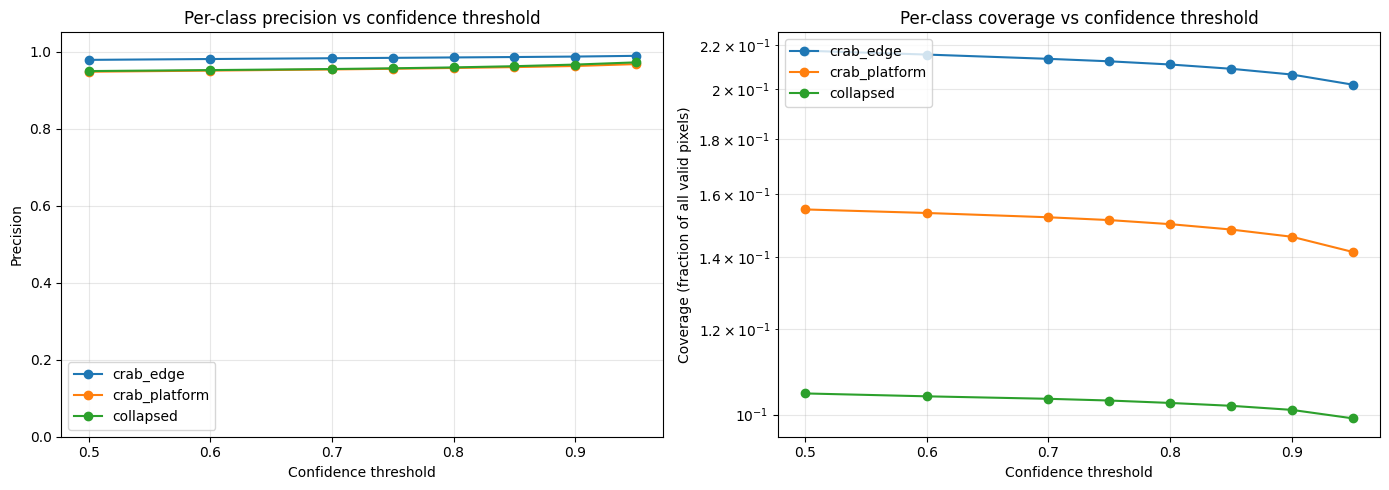

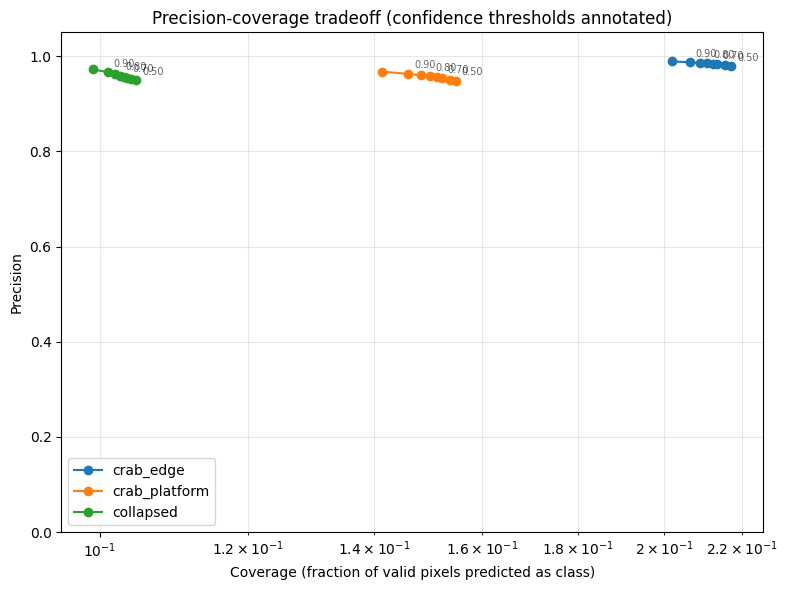

In [ ]:

# 2. Run precision-coverage on the validation set to choose thresholds
print("\nPrecision-coverage analysis on val set:")
pc_results_val = mu.evaluate_precision_coverage(
    model=model,
    loader=val_loader,
    num_classes=Config.N_CLASSES,
    ignore_index=Config.IGNORE_INDEX,
    device=device,
)

# Visualize so you can sanity-check before committing thresholds
mu.plot_precision_coverage(
    pc_results_val,
    class_names=Config.CLASS_NAMES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
)
mu.plot_precision_vs_coverage(
    pc_results_val,
    class_names=Config.CLASS_NAMES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
)
mu.print_precision_coverage_table(
    pc_results_val,
    class_names=Config.CLASS_NAMES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
)


#Choice point!

Use above table to set Config.CONFIDENCE_THRESHOLDS by talking with team.

The code below assumes you want to optimize precision at some value across classes.

Better to set by team decision?

In [ ]:
targets = {
    3: ('precision', 0.90),   # crab_edge: precision floor
    4: ('recall',    0.40),   # crab_platform: recall floor
    5: ('recall',    0.45),   # collapsed: recall floor
}
Config.CONFIDENCE_THRESHOLDS = mu.pick_thresholds_per_class(pc_results_val, targets)
print(f"Chosen thresholds: {Config.CONFIDENCE_THRESHOLDS}")

  class 3: threshold=0.50  precision=0.978  recall=0.870  f1=0.921   [precision=0.9]
  class 4: threshold=0.95  precision=0.968  recall=0.896  f1=0.930   [recall=0.4]
  class 5: threshold=0.95  precision=0.972  recall=0.922  f1=0.947   [recall=0.45]
Chosen thresholds: {3: 0.5, 4: 0.95, 5: 0.95}


In [ ]:
# 4. (Optional) Verify on the held-out test set so the precision numbers
#    you report aren't from the same data you tuned thresholds on
print("\nVerification on test set (using thresholds chosen from val):")
pc_results_test = mu.evaluate_precision_coverage(
    model=model,
    loader=test_loader,
    num_classes=Config.N_CLASSES,
    ignore_index=Config.IGNORE_INDEX,
    device=device,
)
mu.print_precision_coverage_table(
    pc_results_test,
    class_names=Config.CLASS_NAMES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
)



Verification on test set (using thresholds chosen from val):

Class 3 (crab_edge):
  threshold   precision      recall    coverage
       0.50      0.9547      0.9757      0.1794
       0.60      0.9589      0.9731      0.1782
       0.70      0.9633      0.9692      0.1766
       0.75      0.9656      0.9663      0.1757
       0.80      0.9682      0.9620      0.1744
       0.85      0.9711      0.9554      0.1727
       0.90      0.9747      0.9461      0.1704
       0.95      0.9802      0.9325      0.1670

Class 4 (crab_platform):
  threshold   precision      recall    coverage
       0.50      0.9575      0.9604      0.1781
       0.60      0.9584      0.9567      0.1772
       0.70      0.9591      0.9518      0.1762
       0.75      0.9594      0.9482      0.1754
       0.80      0.9596      0.9428      0.1744
       0.85      0.9598      0.9360      0.1731
       0.90      0.9601      0.9269      0.1714
       0.95      0.9605      0.9083      0.1679

Class 5 (collapsed):
  th

##Here is chance to set them by hand

Could be based on Precision, Recall or some mixture per class. In essence, the thresholds act as gate on argmax of raw probs in production. If argmax class is not above its threshold value, it is put in "no decision".

Note that abstain code runs first producing an abstrain-review set, then the gating on this threshold runs to take rest and decide if they go in no decision (not same as abstain set).

In [ ]:
#Config.CONFIDENCE_THRESHOLDS = {}

In [ ]:
# 5. NOW save artifacts — Config.CONFIDENCE_THRESHOLDS is populated
from datetime import datetime
artifact_dir = f"{paths['runs_dir']}/run_{datetime.now():%Y-%m-%d_%H-%M-%S}"
os.makedirs(artifact_dir, exist_ok=True)
print(f"Run output: {artifact_dir}")

mu.save_training_artifacts(
    output_dir=artifact_dir,
    model=model,
    channel_means=channel_means,
    channel_stds=channel_stds,
    training_summary={
        'best_val_miou':     float(best_iou),
        'iou_per_class':     best_ckpt['iou_per_class'],
        'num_train_patches': len(train_patches),
        'num_val_patches':   len(val_patches),
        'num_test_patches':  len(test_patches),
        'threshold_targets': targets,                      # per-class objective+value
        'thresholds':        Config.CONFIDENCE_THRESHOLDS, # the chosen thresholds
    },
    cfg=Config,
)

Run output: /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/synthetic/model/runs/run_2026-08-11_19-09-42
Saved artifacts to /content/drive/MyDrive/salt_marsh/crab_project/WEL/flights_1cm/synthetic/model/runs/run_2026-08-11_19-09-42


###How to interpret the output for your Model 2 labeling decision

The tradeoff plot is the actionable one. Each line is a class; each point is a confidence threshold. The point you want to pick for that class's Model 2 labels is the one where precision is "high enough" (say 0.9+) at the highest possible coverage. If class 3 hits 0.95 precision at coverage 0.05 (5% of marsh pixels labeled), and class 5 only hits 0.7 precision at any threshold, you'd commit class-3 labels to Model 2 confidently and either gather more data for class 5 or accept noisier class-5 labels.

The threshold annotations on the tradeoff plot make this concrete: "to get class 3 at precision ≥ 0.9, threshold at 0.75, which keeps 4% of marsh pixels." That's a sentence you can put in a report.

You might also find that different classes need different thresholds — that's expected, and the per-class precision curve is exactly the right tool for setting them. The standard "single threshold for all classes" rule of thumb (e.g., 0.7) is a starting point, not the final answer.

#Analyze channel importance

In [ ]:
CHANNEL_NAMES = ['0', '1', '2']

In [ ]:

# Quick pass: zero ablation
zero_results = mu.channel_zero_ablation(
    model=model, loader=val_loader,
    num_classes=Config.N_CLASSES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
    channel_names=CHANNEL_NAMES,
    device=device,
)

print(f"Baseline mIoU: {zero_results['baseline_mean_iou']:.4f}")
for name, r in zero_results['per_channel'].items():
    print(f"  zero {name:6s}: mIoU={r['mean_iou']:.4f}  drop={r['drop_from_base']:+.4f}")

# Slower pass: permutation importance
perm_results = mu.channel_permutation_importance(
    model=model, loader=val_loader,
    num_classes=Config.N_CLASSES,
    classes_of_interest=Config.CLASSES_OF_INTEREST,
    channel_names=CHANNEL_NAMES,
    device=device,
    n_repeats=3,
)

print(f"\nPermutation importance (mean ± std over {3} repeats):")
for name, r in perm_results['per_channel'].items():
    print(f"  permute {name:6s}: drop={r['mean_drop']:+.4f} ± {r['std_drop']:.4f}")

Baseline mIoU: 0.8908
  zero 0     : mIoU=0.0954  drop=+0.7954
  zero 1     : mIoU=0.0947  drop=+0.7961
  zero 2     : mIoU=0.5793  drop=+0.3115

Permutation importance (mean ± std over 3 repeats):
  permute 0     : drop=+0.7298 ± 0.0027
  permute 1     : drop=+0.8096 ± 0.0024
  permute 2     : drop=+0.6230 ± 0.0042


In [ ]:
import json, os
with open(os.path.join(paths['_experiments_dir'], 'band_importance.json'), 'w') as f:
    json.dump({'zero': zero_results, 'permutation': perm_results}, f, indent=2, default=float)

##How to interpret the output:

* Big drop when zeroed → model relies heavily on that channel (could be true importance or learned reliance)
* Small drop when zeroed → model isn't using that channel much (might be genuinely useless, or might be that the model leans on other correlated channels)
* Big drop when permuted, small drop when zeroed → model is using the channel's spatial structure but is partially robust to scaling
* Both large → channel is genuinely important
* Both small → channel is probably redundant

A useful pattern is comparing the two: if zeroing gives a big drop but permutation gives a small one, the model is leaning on the channel's value range more than its spatial pattern. This sometimes flags problems — e.g., the model has learned "if NDVI value is low, prediction is X" without using the spatial pattern, which is a clue that the channel is acting more like a scalar gate than a spatial feature.

###When to escalate to retrain ablation:

If zero+permutation suggest a channel might be droppable (mean IoU drop < ~0.01 across both tests), do one retrain without that channel and compare the new baseline. If the retrained model matches the original, drop the channel. If the retrained model loses meaningful IoU even though the inference ablation suggested the channel was unused, the trained model was using it in ways the inference tests didn't capture. Retrain is more expensive but it's the only test that tells you whether a channel should have been there during training.

For the Pan/NDVI/NDRE setup specifically, my prior is that NDVI does the heaviest lifting (vegetation contrast is the cleanest signal), NDRE adds modest value (matters for stress within the vegetated regime), and pan adds spatial resolution that the others can't replace. But that prior is worth nothing compared to actually running the ablation once you have data.

In [ ]:
results = mu.channel_permutation_importance_per_class(
    model, val_loader, num_classes=6,
    ignore_index=Config.IGNORE_INDEX,
    n_repeats=3,
    device=device,
    class_names=Config.CLASS_NAMES,                # dict {0:'other', 1:'healthy_bank', ...}
    band_names=[b[0] for b in Config.BAND_SPEC],   # ['pan_orthomosaic', 'ndvi', 'ndre']
)
# results['drops_mean'][ch, c]   → drop for channel ch on class c
# results['drops'][ch, c, :]     → per-repeat drops (for variance / significance testing)

#Experiment with different thresholding approaches

In [ ]:
import sklearn

# Compute probs once
probs, true = predict_probs(model, val_loader, ignore_index=Config.IGNORE_INDEX, device=device)

# Try different rules — fast since model doesn't run again
for rule_name, rule_fn in [
    ('argmax',             lambda p: rule_argmax(p)),
    ('soft_cascade_05',    lambda p: rule_soft_cascade(p, bank_threshold=0.5)),
    ('soft_cascade_07',    lambda p: rule_soft_cascade(p, bank_threshold=0.7)),
    ('priority_all',       lambda p: rule_priority(p, Config.CONFIDENCE_THRESHOLDS, Config.PRIORITY)),
    ('priority_crab_only', lambda p: rule_priority(p, Config.CONFIDENCE_THRESHOLDS, [5, 4, 3])),
]:
    pred = rule_fn(probs)
    cm = sklearn.metrics.confusion_matrix(true, pred, labels=range(len(Config.CLASS_NAMES)))
    print(f"\n=== {rule_name} ===")
    mu.display_confusion_matrix(cm, list(Config.CLASS_NAMES.values()), normalize='recall')

#Look at confidence levels

In [ ]:
import sklearn.metrics
import numpy as np
import collections


# ─── Helper: evaluate one rule (handles abstention) ───
def evaluate_rule(true, pred, class_names, abstain_label=255):
    """Show confusion matrix for non-abstained pixels, report abstention rate."""
    valid = pred != abstain_label
    n_abstained = int((~valid).sum())
    pct = 100 * n_abstained / len(pred) if len(pred) else 0.0
    print(f"  Pixels: {valid.sum():,}/{len(pred):,} kept  ·  "
          f"{n_abstained:,} abstained ({pct:.1f}%)")
    if valid.sum() == 0:
        print("  (no predictions to score)")
        return
    cm = sklearn.metrics.confusion_matrix(
        true[valid], pred[valid], labels=range(len(class_names))
    )
    mu.display_confusion_matrix(cm, class_names, normalize='recall')


# ─── All rules to try ───
class_names = list(Config.CLASS_NAMES.values())

rules = [
    # Pure argmax (no thresholding, no abstain)
    ('argmax',
        lambda p: rule_argmax(p)),

    # Argmax + abstain on low max-confidence
    ('argmax_abstain_05',
        lambda p: mu.rule_argmax_abstain(p, min_confidence=0.5)),
    ('argmax_abstain_07',
        lambda p: mu.rule_argmax_abstain(p, min_confidence=0.7)),

    # Argmax + abstain on close top-2 (catches "tied" pixels)
    ('margin_abstain_015',
        lambda p: mu.rule_margin_abstain(p, min_margin=0.15)),
    ('margin_abstain_025',
        lambda p: mu.rule_margin_abstain(p, min_margin=0.25)),

    # Argmax + abstain on high entropy (catches spread distributions)
    ('entropy_abstain_15',
        lambda p: mu.rule_entropy_abstain(p, max_entropy=1.5)),

    # Soft cascade — sum P(banks) > threshold, then argmax among banks
    ('soft_cascade_05',
        lambda p: rule_soft_cascade(p, bank_threshold=0.5)),
    ('soft_cascade_07',
        lambda p: rule_soft_cascade(p, bank_threshold=0.7)),

    # Priority — walk classes in PRIORITY order; first to pass threshold wins
    ('priority_all',
        lambda p: rule_priority(p, Config.CONFIDENCE_THRESHOLDS, Config.PRIORITY)),
    ('priority_crab_only',
        lambda p: rule_priority(p, Config.CONFIDENCE_THRESHOLDS, [5, 4, 3])),
]


# ─── Run each rule ───
for name, rule_fn in rules:
    print(f"\n{'='*70}\n=== {name} ===\n{'='*70}")
    pred = rule_fn(probs)
    evaluate_rule(true, pred, class_names)

In [ ]:
print(f"\n{'='*70}\n=== margin tie diagnostics ===\n{'='*70}")
sorted_idx = np.argsort(probs, axis=1)
sorted_probs = np.take_along_axis(probs, sorted_idx, axis=1)
margin = sorted_probs[:, -1] - sorted_probs[:, -2]

for thresh in [0.15, 0.25]:
    tied = margin < thresh
    print(f"\nmargin < {thresh}: {tied.sum():,} pixels ({100*tied.mean():.1f}%)")
    if tied.sum() == 0:
        continue
    top1 = sorted_idx[:, -1][tied]
    top2 = sorted_idx[:, -2][tied]
    pairs = [tuple(sorted([t1, t2])) for t1, t2 in zip(top1, top2)]
    counter = collections.Counter(pairs)
    print("  Top tied pairs (class_a ↔ class_b → count):")
    for (a, b), n in counter.most_common(5):
        print(f"    {class_names[a]:18s} ↔ {class_names[b]:18s}  {n:,}")

<img src='https://www.dropbox.com/scl/fi/oyu1fdcvn21iejfclvunu/Screenshot-2026-06-08-at-11.58.13-AM.png?rlkey=kkf2krz8plyov1mcfxapqswty&dl=1'>

In [ ]:
foobar()

#Save for use in production